# PULSE GUARD
## Environment Setup

```shell
python3 -m pip install virtualenv
virtualenv --python=python3.14 .venv

source .venv/bin/activate

.venv/bin/python -m pip install ipykernel ipywidgets
```

## PHASE 1: Data Collection
For this study, we are using three publicly available datasets.
- Sarkar 2024 - https://www.kaggle.com/datasets/suchintikasarkar/sentiment-analysis-for-mental-health
- Komati 2021 - https://www.kaggle.com/datasets/nikhileswarkomati/suicide-watch
- SDCNL 2021 - https://github.com/ayaanzhaque/SDCNL

### Install packages

Install the packages used to download, explore, and plot the data.


In [2]:
# install packages
%pip install -q kagglehub pandas matplotlib nltk

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


### Set up the data folder

Import the libraries and create a folder for the raw CSV files.


In [1]:
import kagglehub
import shutil
from pathlib import Path
from urllib.request import urlopen

# raw data path
RAW_DIR = Path("data/raw")
RAW_DIR.mkdir(parents=True, exist_ok=True)


c:\Users\Admin\Documents\Salford\Salcore AI\PulseGuard\notebooks\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Download functions

Download CSV files from Kaggle and GitHub. Reuse files that already exist.


In [2]:
# function to download datasets from kaggle
def fetch_kaggle_csv(dataset, filename):
    destination = RAW_DIR / filename
    if not destination.exists():
        folder = Path(kagglehub.dataset_download(dataset))
        csv_files = list(folder.rglob("*.csv"))
        if len(csv_files) != 1:
            raise ValueError(f"Expected one CSV in {dataset}, found {len(csv_files)}")
        shutil.copyfile(csv_files[0], destination)
    print(f"Ready: {destination}")
    return destination


# function to download datasets from github
def fetch_github_csv(url, filename):
    destination = RAW_DIR / filename
    if not destination.exists():
        with urlopen(url, timeout=60) as response:
                data = response.read()
        destination.write_bytes(data)
    print(f"Ready: {destination}")
    return destination

### Download the datasets

Download the Sarkar, Komati, and SDCNL datasets.


In [3]:
sarkar_path = fetch_kaggle_csv(
    "suchintikasarkar/sentiment-analysis-for-mental-health",
    "sarkar_2024.csv"
)

komati_path = fetch_kaggle_csv(
    "nikhileswarkomati/suicide-watch",
    "komati_2021.csv"
)

sdcnl_path = fetch_github_csv(
    "https://raw.githubusercontent.com/ayaanzhaque/SDCNL/main/data/combined-set.csv",
    "sdcnl_2021.csv",
)

100%|██████████| 11.1M/11.1M [00:01<00:00, 7.70MB/s]


Extracting files...
Ready: data\raw\sarkar_2024.csv


100%|██████████| 60.6M/60.6M [00:11<00:00, 5.63MB/s]

Extracting files...


Ready: data\raw\komati_2021.csv
Ready: data\raw\sdcnl_2021.csv


### Load the datasets

Read each CSV into a DataFrame and check its size and columns.


In [4]:
# load datasets into pandas dataframe
import pandas as pd

DATASET_PATHS = [
    ("sarkar_2024", sarkar_path),
    ("komati_2021", komati_path),
    ("sdcnl_2021", sdcnl_path)
]

dataframes = {}

for name, path in DATASET_PATHS:
        frame = pd.read_csv(path)
        dataframes[name] = frame
        
        print(name)
        print("-" * 10)
        print(f"shape: {frame.shape[0]} rows x {frame.shape[1]} columns")
        print(f"columns: {list(frame.columns)}")
        print("\n")

sarkar_2024
----------
shape: 53043 rows x 3 columns
columns: ['Unnamed: 0', 'statement', 'status']


komati_2021
----------
shape: 232074 rows x 3 columns
columns: ['Unnamed: 0', 'text', 'class']


sdcnl_2021
----------
shape: 1895 rows x 14 columns
columns: ['Unnamed: 0.1', 'Unnamed: 0', 'title', 'selftext', 'author', 'num_comments', 'is_suicide', 'url', 'selftext_clean', 'title_clean', 'author_clean', 'selftext_length', 'title_length', 'megatext_clean']




## PHASE 2: Exploratory Data Analysis

### Preview the data

Show the first three rows of each dataset.


In [5]:
for (name, frame) in dataframes.items():
        print(name)
        display(frame.head(3))


sarkar_2024


,Unnamed: 0,statement,status
0,0,oh my gosh,Anxiety
1,1,"trouble sleeping, confused mind, restless hear...",Anxiety
2,2,"All wrong, back off dear, forward doubt. Stay ...",Anxiety


komati_2021


,Unnamed: 0,text,class
0,2,Ex Wife Threatening SuicideRecently I left my ...,suicide
1,3,Am I weird I don't get affected by compliments...,non-suicide
2,4,Finally 2020 is almost over... So I can never ...,non-suicide


sdcnl_2021


,Unnamed: 0.1,Unnamed: 0,title,selftext,author,num_comments,is_suicide,url,selftext_clean,title_clean,author_clean,selftext_length,title_length,megatext_clean
0,0,339,Need help,Hi I don't really know how to phrase this situ...,F4GG0T_,6,0,https://www.reddit.com/r/depression/comments/f...,hi really know phrase situation try life reall...,need help,f 4 gg 0,2502,9,f 4 gg 0 hi really know phrase situation try l...
1,1,1386,feeling so overwhelmed and hopeless,i have been so depressed these past couple wee...,thiccbarbie420,2,1,https://www.reddit.com/r/SuicideWatch/comments...,depressed past couple week ever since got back...,feeling overwhelmed hopeless,th icc barbie 420,843,35,th icc barbie 420 depressed past couple week e...
2,2,544,"Nothing matters anymore, getting worse",Hi..I don't know where else to go. I am devast...,mjdg25,3,0,https://www.reddit.com/r/depression/comments/f...,hi know else go devastated right feeling like ...,nothing matter anymore getting worse,mj g 25,1909,38,mj g 25 hi know else go devastated right feeli...


### Keep the required columns

Keep the text and class columns from each dataset.


In [6]:
REQUIRED_COLS = {
    "sarkar_2024": ["statement", "status"],
    "komati_2021": ["text", "class"],
    "sdcnl_2021": ["selftext", "is_suicide"],
}

for name, cols in REQUIRED_COLS.items():
    dataframes[name] = dataframes[name][cols].reset_index(drop=True)
    print(name)
    display(dataframes[name].head(3))


sarkar_2024


,statement,status
0,oh my gosh,Anxiety
1,"trouble sleeping, confused mind, restless hear...",Anxiety
2,"All wrong, back off dear, forward doubt. Stay ...",Anxiety


komati_2021


,text,class
0,Ex Wife Threatening SuicideRecently I left my ...,suicide
1,Am I weird I don't get affected by compliments...,non-suicide
2,Finally 2020 is almost over... So I can never ...,non-suicide


sdcnl_2021


,selftext,is_suicide
0,Hi I don't really know how to phrase this situ...,0
1,i have been so depressed these past couple wee...,1
2,Hi..I don't know where else to go. I am devast...,0


### Check missing values

Count missing values in each dataset.


In [7]:
# missing values
for name, frame in dataframes.items():
    print(name)
    print(f"{frame.isna().sum()}")
    print()


sarkar_2024
statement    362
status         0
dtype: int64

komati_2021
text     0
class    0
dtype: int64

sdcnl_2021
selftext      0
is_suicide    0
dtype: int64



### Sarkar class counts

Show how many posts belong to each original class.


status
Normal                  16351
Depression              15404
Suicidal                10653
Anxiety                  3888
Bipolar                  2877
Stress                   2669
Personality disorder     1201
Name: count, dtype: int64


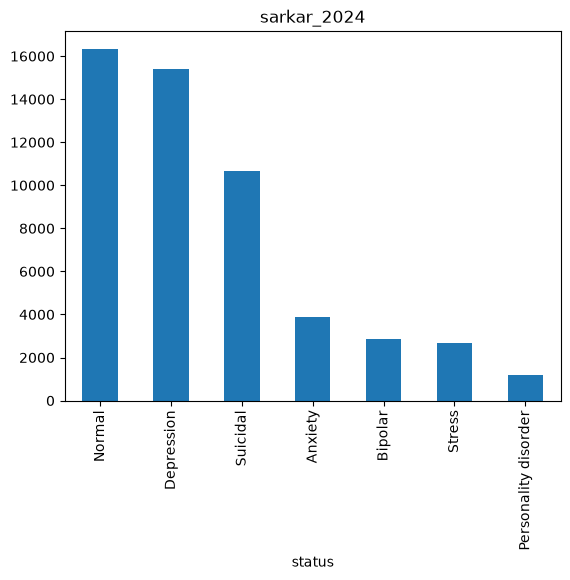

In [8]:
sarkar_2024_value_counts = dataframes["sarkar_2024"]["status"].value_counts()
sarkar_2024_value_counts.plot.bar(title="sarkar_2024")
print(sarkar_2024_value_counts)


### Select Sarkar classes

Keep only Normal, Depression, and Suicidal posts.


In [9]:
CLASS_LABELS = ["Normal", "Depression", "Suicidal"]

df_sarkar = dataframes["sarkar_2024"]
df_sarkar = df_sarkar[df_sarkar["status"].isin(CLASS_LABELS)].reset_index(drop=True)

dataframes["sarkar_2024"] = df_sarkar
sarkar_2024_value_counts = df_sarkar["status"].value_counts()

display(sarkar_2024_value_counts)


status
Normal        16351
Depression    15404
Suicidal      10653
Name: count, dtype: int64

### Komati class counts

Show the number of posts in each Komati class.


class
suicide        116037
non-suicide    116037
Name: count, dtype: int64


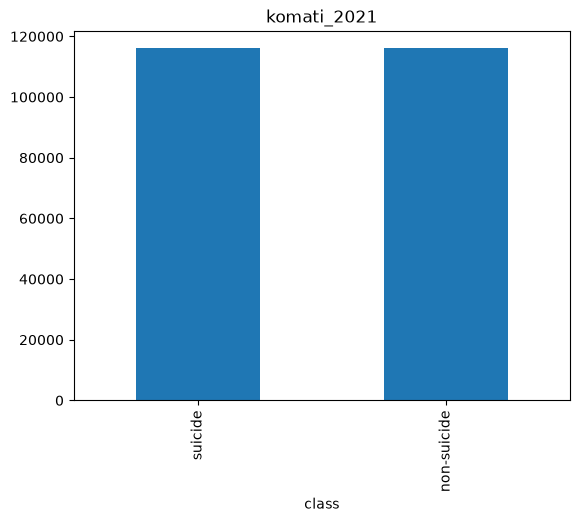

In [10]:
komati_2021_value_counts = dataframes["komati_2021"]["class"].value_counts()
komati_2021_value_counts.plot.bar(title="komati_2021")
print(komati_2021_value_counts)


### Prepare Komati

Rename the text and class columns, map the labels.


In [11]:
# map 'class' to 'status'
df_komati = dataframes["komati_2021"]
df_komati["status"] = df_komati["class"].map(
    {"suicide": "Suicidal", "non-suicide": "Normal"}
)

# rename text to statement
df_komati = df_komati.rename(columns={"text": "statement"})[["statement", "status"]]

dataframes["komati_2021"] = df_komati
komati_2021_value_counts = df_komati["status"].value_counts()
print(komati_2021_value_counts)


status
Suicidal    116037
Normal      116037
Name: count, dtype: int64


### SDCNL class counts

Show the number of posts for each SDCNL label.


is_suicide
1    980
0    915
Name: count, dtype: int64


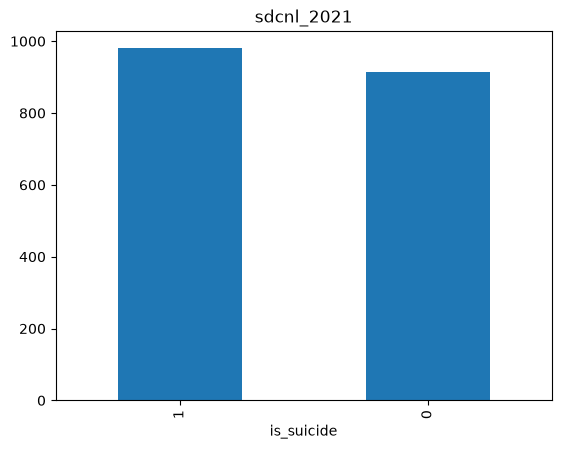

In [12]:
sdcnl_2021_value_counts = dataframes["sdcnl_2021"]["is_suicide"].value_counts()
sdcnl_2021_value_counts.plot.bar(title="sdcnl_2021")
print(sdcnl_2021_value_counts)


### Prepare SDCNL

Map 1 to Suicidal and 0 to Depression. Keep the statement and status columns.


In [13]:
# map 'is_suicide' to 'status'
df_sdcnl = dataframes["sdcnl_2021"]
df_sdcnl["status"] = df_sdcnl["is_suicide"].map(
    {1: "Suicidal", 0: "Depression"}
)

# rename selftext to statement
df_sdcnl = df_sdcnl.rename(columns={"selftext": "statement"})[["statement", "status"]]

dataframes["sdcnl_2021"] = df_sdcnl
sdcnl_2021_value_counts = df_sdcnl["status"].value_counts()
print(sdcnl_2021_value_counts)


status
Suicidal      980
Depression    915
Name: count, dtype: int64


### Combine the datasets

Combine the three DataFrames and show the final class counts and total rows.


Final dataset for analysis
------------------------------
status
Normal        132388
Suicidal      127670
Depression     16319
Name: count, dtype: int64
------------------------------
Total rows: 276,377


<Axes: title={'center': 'Final Dataset'}, xlabel='status'>

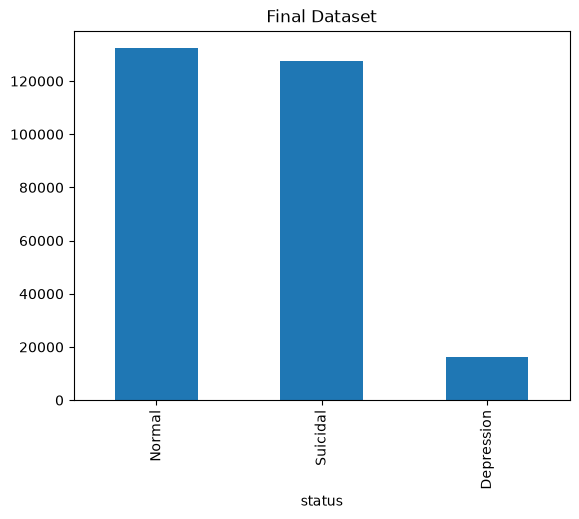

In [14]:
df = pd.concat(
    [frame.assign(source=name) for name, frame in dataframes.items()],
    ignore_index=True,
)
df_value_counts = df["status"].value_counts()

print("Final dataset for analysis")
print("-" * 30)
print(df_value_counts)
print("-" * 30)
print(f"Total rows: {len(df):,}")
df_value_counts.plot.bar(title="Final Dataset")


### Class counts by source
Show how many posts each dataset contributes to each class. Missing labels are counted separately below.

In [15]:
display(pd.crosstab(df["source"], df["status"]).reindex(columns=CLASS_LABELS, fill_value=0))

status,Normal,Depression,Suicidal
source,,,
komati_2021,116037,0,116037
sarkar_2024,16351,15404,10653
sdcnl_2021,0,915,980


### Missing and blank values after merging
Count missing text, whitespace-only text, and missing labels. These checks do not remove rows.

In [16]:
blank_text = df["statement"].astype("string").str.strip().eq("").fillna(False)

print(f"Missing text: {df['statement'].isna().sum():,}")
print(f"Blank text: {blank_text.sum():,}")
print(f"Missing labels: {df['status'].isna().sum():,}")

Missing text: 9
Blank text: 0
Missing labels: 0


### Duplicate statements and conflicting labels
Compare text after ignoring capitalisation and extra spaces. Count repeated rows, texts shared across datasets, and texts assigned different labels. Missing and blank text are excluded. Original text and rows remain unchanged.

In [17]:
text_check = df.loc[
    df["statement"].notna() & ~blank_text, ["statement", "status", "source"]
].copy()

text_check["text_key"] = (
    text_check["statement"].str.lower().str.replace(r"\s+", " ", regex=True).str.strip()
)

text_summary = text_check.groupby("text_key").agg(
    rows=("source", "size"),
    sources=("source", "nunique"),
    labels=("status", "nunique"),
)

print(f"Repeated rows beyond the first copy: {text_check['text_key'].duplicated().sum():,}")
print(f"Distinct texts appearing in multiple datasets: {(text_summary['sources'] > 1).sum():,}")
print(f"Distinct texts with conflicting labels: {(text_summary['labels'] > 1).sum():,}")

conflicting_texts = text_summary.index[text_summary["labels"] > 1]
print("Examples of conflicting labels:")
display(text_check.loc[
    text_check["text_key"].isin(conflicting_texts),
    ["text_key", "source", "status", "statement"],
].sort_values("text_key").head(10).drop(columns="text_key"))

Repeated rows beyond the first copy: 820
Distinct texts appearing in multiple datasets: 3
Distinct texts with conflicting labels: 18
Examples of conflicting labels:


,source,status,statement
23010,sarkar_2024,Depression,#NAME?
22872,sarkar_2024,Depression,#NAME?
22802,sarkar_2024,Depression,#NAME?
21961,sarkar_2024,Depression,#NAME?
20222,sarkar_2024,Depression,#NAME?
19731,sarkar_2024,Suicidal,#NAME?
27834,sarkar_2024,Normal,#NAME?
17463,sarkar_2024,Depression,#NAME?
19053,sarkar_2024,Depression,#NAME?
26748,sarkar_2024,Normal,#NAME?


### Example statements

Show five random statements from each class.


In [18]:
for label in CLASS_LABELS:
    print(f"\n{label.upper()}")
    print("-" * 10)

    statements_for_label = df[df["status"] == label]["statement"]
    sampled_statements = statements_for_label.sample(n=5, random_state=42)

    for i, text in enumerate(sampled_statements, 1):
        print(f"{i}. {text}\n")



NORMAL
----------
1. I get to be in quarantine Im sick so ill be quarantined for a bit. Im actually hyped

2. attention guys with perms get rid of it asap it looks like you glued your pubes to your forehead

3. I was today years old when I found out the pink marks on my stomach are actually stretch marks. HOW TF DID I ONLY FIGURE THIS OUT TODAY? 

Like I didn't know what tf they were until my fellow chubby friend took off his shirt to change and I noticed the same pink marks. Like obviously I know I'm overweight but I didn't know it created these stretch marks, I thought it was something else. What exactly, idk. 

Okay it's 12am I'm tired as frick, goodnight.

4. bivancamp aw that suuuucks sorry dear

5. So i have this gf.... She's so damn cute god
Say hi to her
Not forcing u, just asking for a HI :)


DEPRESSION
----------
1. I have never gone in to be diagnosed, so I do not want to jump the gun on labels or anything, but I have had quite the wild ride with depression throughout a go

### Text lengths

Compare character and word counts across classes, including the median and 95th percentile.


In [19]:
df["char_len"] = df["statement"].str.len()
df["word_len"] = df["statement"].str.split().str.len()

print("Character Length")
display(df.groupby("status")["char_len"].describe(percentiles=[0.5, 0.95]))

print("Word Length")
display(df.groupby("status")["word_len"].describe(percentiles=[0.5, 0.95]))


Character Length


,count,mean,std,min,50%,95%,max
status,,,,,,,
Depression,16319.0,850.558919,982.461810,3.0,562.0,2503.10,19822.0
Normal,132380.0,299.716211,760.246766,2.0,148.0,971.05,40106.0
Suicidal,127669.0,1022.130509,1307.301016,3.0,632.0,3186.60,40297.0


Word Length


,count,mean,std,min,50%,95%,max
status,,,,,,,
Depression,16319.0,169.037318,193.761437,1.0,113.0,496.1,4239.0
Normal,132380.0,55.763431,131.453489,1.0,28.0,186.0,8220.0
Suicidal,127669.0,197.626683,250.793161,1.0,123.0,616.0,9684.0


### Word counts
Show the 15 most common words in each class, excluding English stopwords. Use up to 3,000 posts per class. Each bar counts how many times the word appears.

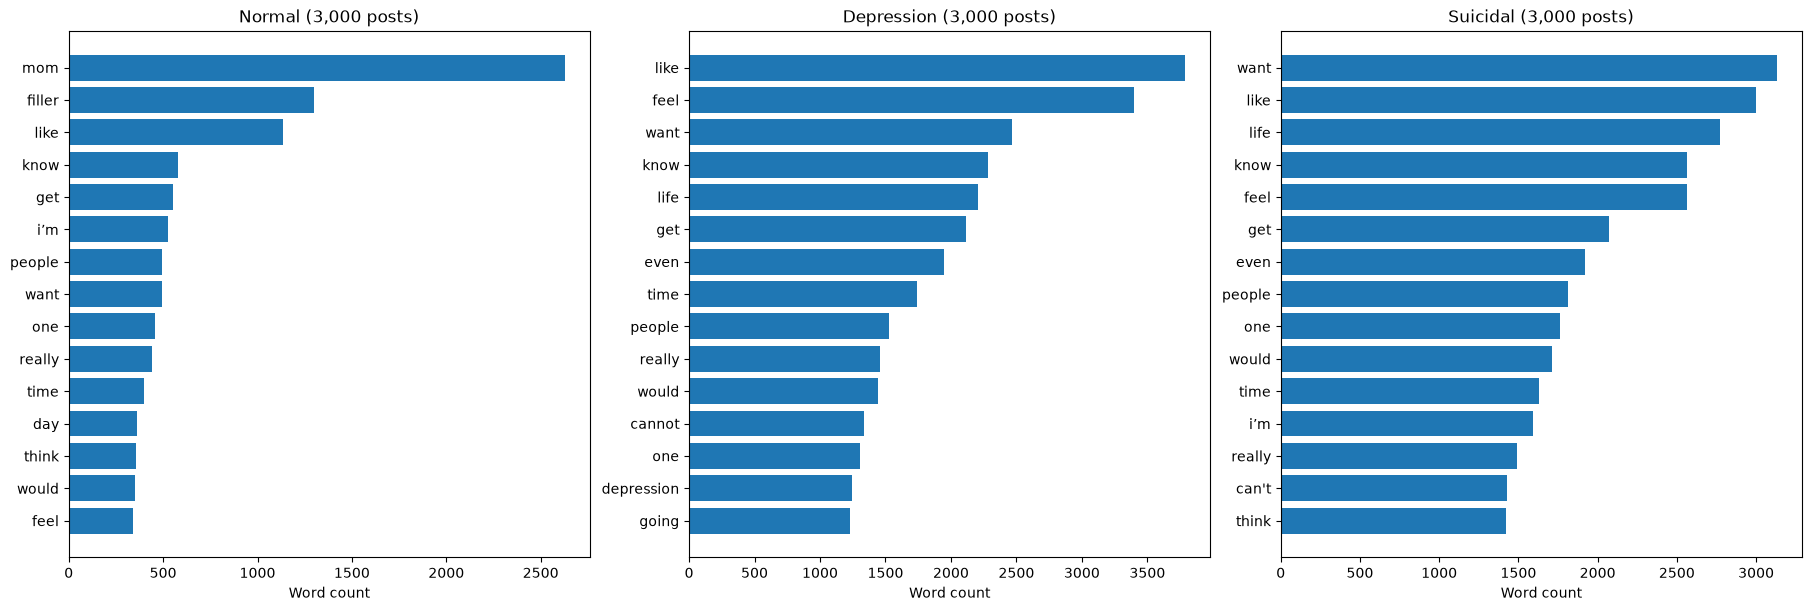

In [20]:
import re
import nltk
import matplotlib.pyplot as plt
from collections import Counter
from nltk.corpus import stopwords

nltk.download("stopwords", quiet=True)
STOPWORDS = set(stopwords.words("english"))

samples = {}
for label in CLASS_LABELS:
    posts = df.loc[df["status"] == label, "statement"].dropna()
    posts = posts[posts.str.strip().ne("")]
    samples[label] = posts.sample(n=min(3000, len(posts)), random_state=42)

fig, axes = plt.subplots(1, 3, figsize=(18, 6), layout="constrained")
for ax, label in zip(axes, CLASS_LABELS):
    counts = Counter()
    for text in samples[label]:
        words = re.findall(r"[a-z]+(?:['’][a-z]+)?", text.lower())
        counts.update(word for word in words if word not in STOPWORDS and len(word) > 2)

    top = counts.most_common(15)
    ax.barh([word for word, count in top], [count for word, count in top])
    ax.invert_yaxis()
    ax.set_title(f"{label} ({len(samples[label]):,} posts)")
    ax.set_xlabel("Word count")
    ax.xaxis.get_major_locator().set_params(integer=True)

plt.show()

### Two-word ngrams

Show the 15 most common neighbouring two-word phrases in each class. Count each occurrence, excluding phrases made entirely of stopwords.


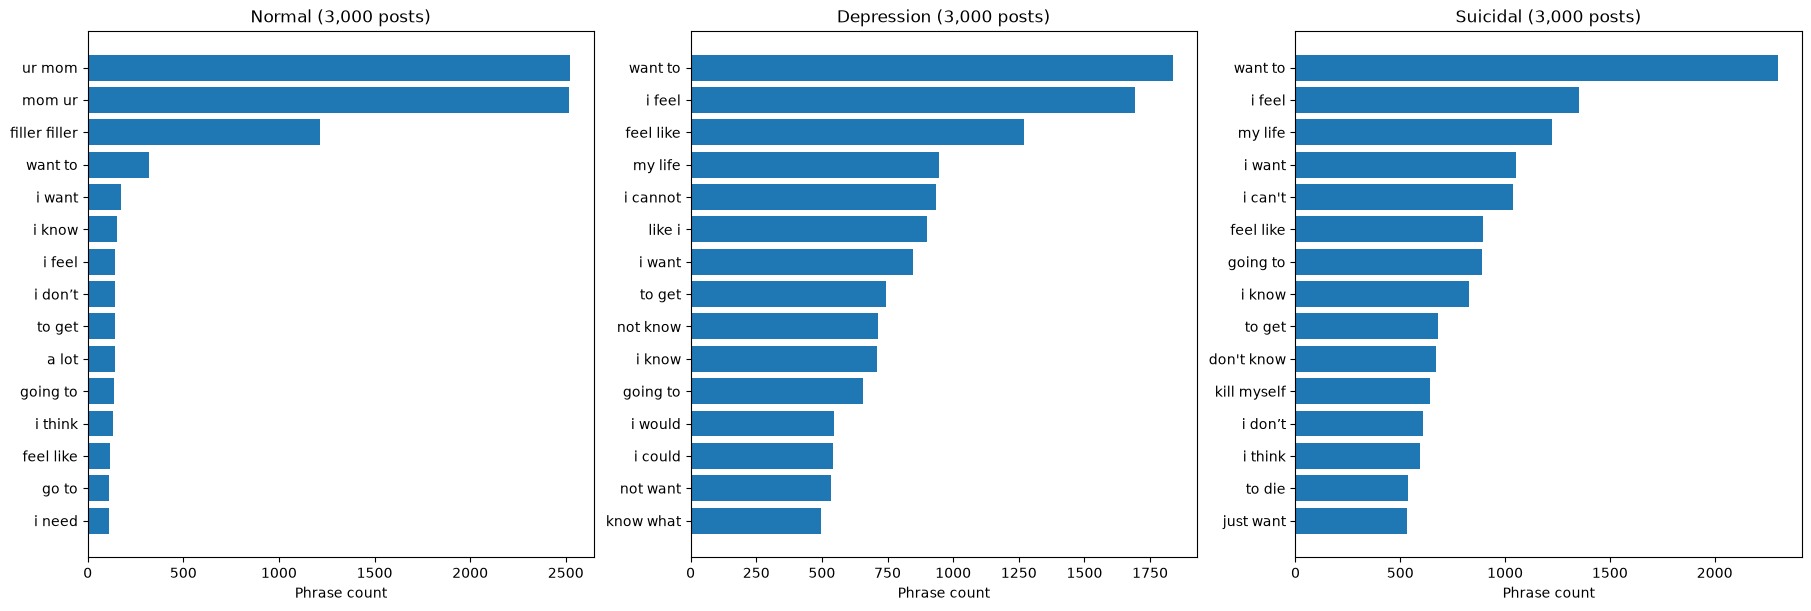

In [21]:
phrase_counts = {}
for label in CLASS_LABELS:
    counts = Counter()
    for text in samples[label]:
        for sentence in re.split(r"[.!?;:,\n]+", text.lower()):
            words = re.findall(r"[a-z]+(?:['’][a-z]+)?", sentence)
            counts.update(
                f"{first} {second}"
                for first, second in zip(words, words[1:])
                if first not in STOPWORDS or second not in STOPWORDS
            )
    phrase_counts[label] = counts

fig, axes = plt.subplots(1, 3, figsize=(18, 6), layout="constrained")
for ax, label in zip(axes, CLASS_LABELS):
    top = phrase_counts[label].most_common(15)
    ax.barh([phrase for phrase, count in top], [count for phrase, count in top])
    ax.invert_yaxis()
    if not top:
        ax.text(0.5, 0.5, "No phrases to display", ha="center", transform=ax.transAxes)
    ax.set_title(f"{label} ({len(samples[label]):,} posts)")
    ax.set_xlabel("Phrase count")
    ax.xaxis.get_major_locator().set_params(integer=True)

plt.show()


### Distinct two-word phrases
Show the 15 most common phrases found only in one class's sample and absent from the other two samples. 

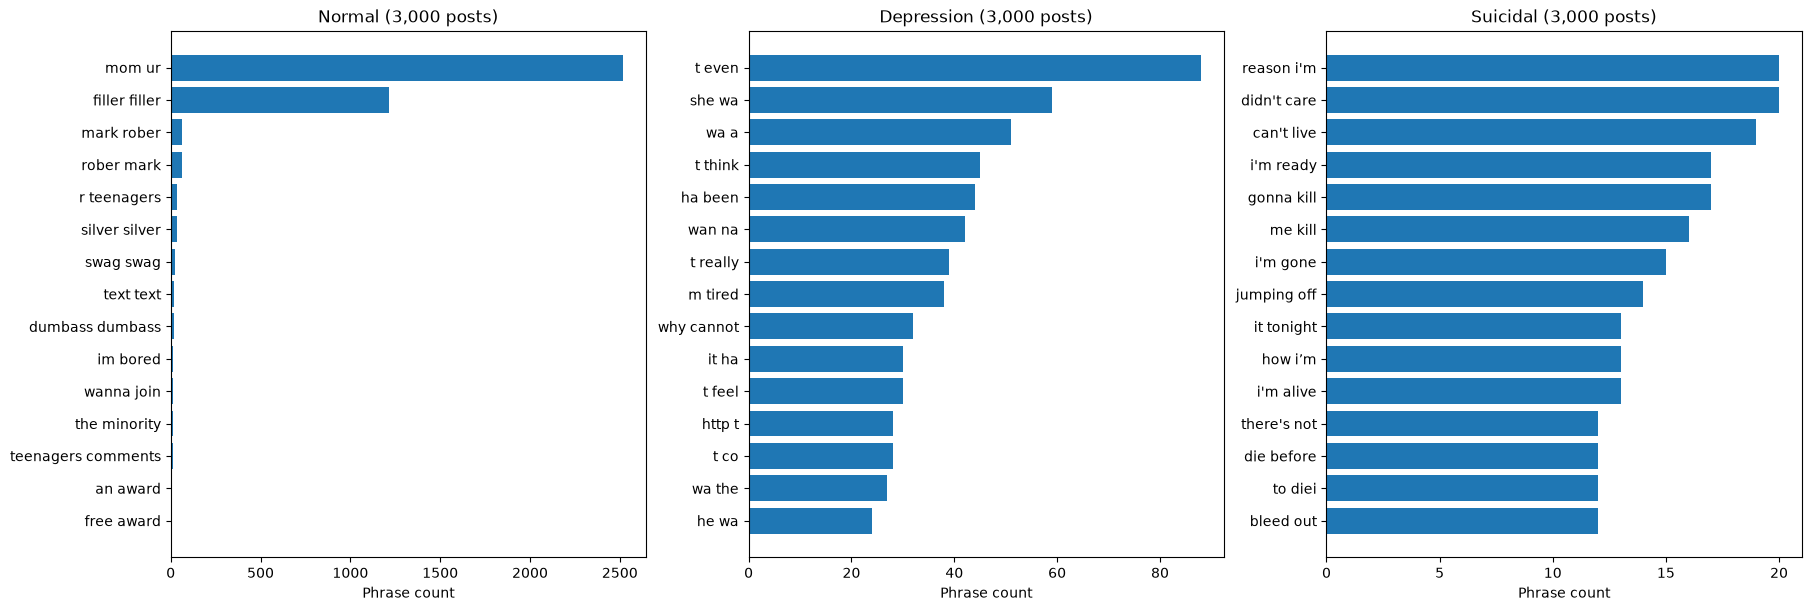

In [22]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6), layout="constrained")
for ax, label in zip(axes, CLASS_LABELS):
    other_phrases = set()
    for other in CLASS_LABELS:
        if other != label:
            other_phrases.update(phrase_counts[other])

    distinct = Counter({
        phrase: count for phrase, count in phrase_counts[label].items()
        if phrase not in other_phrases
    })
    top = distinct.most_common(15)
    ax.barh([phrase for phrase, count in top], [count for phrase, count in top])
    ax.invert_yaxis()
    if not top:
        ax.text(0.5, 0.5, "No distinct phrases", ha="center", transform=ax.transAxes)
    ax.set_title(f"{label} ({len(samples[label]):,} posts)")
    ax.set_xlabel("Phrase count")
    ax.xaxis.get_major_locator().set_params(integer=True)

plt.show()